# Text Encoding

Goal is to:
1. Implement Bag-of-Words (BoW) encoding
2. Implement TF-IDF encoding
3. Compare vocab sizes
4. Visualize word frequencies

In [1]:
# Step 1: Import necessary libraries

import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Load a subset of data

base_dir = "/Users/mimi/Desktop/nlp project/aclImdb"
train_pos_dir = os.path.join(base_dir, "train/pos")
train_neg_dir = os.path.join(base_dir, "train/neg")

def load_reviews(directory, limit=1000):
    data = []
    for x, filename in enumerate(os.listdir(directory)):
        if x >= limit:
            break
        with open(os.path.join(directory, filename), "r", encoding="utf-8") as f:
            data.append(f.read())
    return data

pos_reviews = load_reviews(train_pos_dir, limit=1000)
neg_reviews = load_reviews(train_neg_dir, limit=1000)

all_reviews = pos_reviews + neg_reviews
labels = [1] * len(pos_reviews) + [0] * len(neg_reviews)

print("Total reviews loaded:", len(all_reviews))

Total reviews loaded: 2000


## Step 3: BoW (Bag-Of Words) Encoding

Convert text into a sparse matric of word counts

In [3]:
# Step 3: BoW

bow_vectorizer = CountVectorizer(max_features=5000, stop_words="english")

X_bow = bow_vectorizer.fit_transform(all_reviews)

print("BOW shape:", X_bow.shape)
print("Vocabulary size (BoW):", len(bow_vectorizer.get_feature_names_out()))

BOW shape: (2000, 5000)
Vocabulary size (BoW): 5000


## Step 4: TF-IDF Encoding

TF-IDF assigns weights based on frequency in document and rarity across documents.

In [4]:
# Step 4: TF-IDF

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

X_tfidf = tfidf_vectorizer.fit_transform(all_reviews)

print("TF-IDF shape:", X_tfidf.shape)
print("Vocabulary size (TF-IDF):", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF shape: (2000, 5000)
Vocabulary size (TF-IDF): 5000


/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_29135/622902902.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=bow_freq, palette="Blues_d")


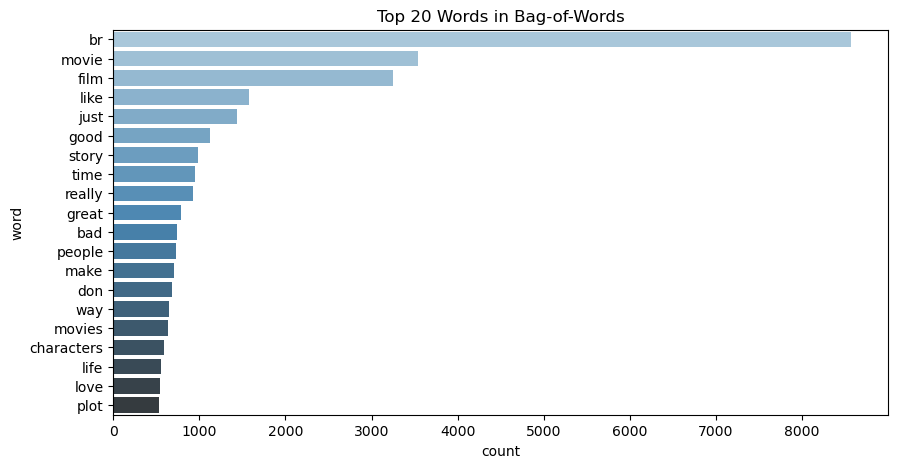

In [5]:
# Step 5, a: Compare Top Words in BoW

word_counts = X_bow.toarray().sum(axis=0)
words = bow_vectorizer.get_feature_names_out()
bow_freq = pd.DataFrame({'word': words, 'count': word_counts})
bow_freq = bow_freq.sort_values(by='count', ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=bow_freq, palette="Blues_d")
plt.title("Top 20 Words in Bag-of-Words")
plt.show()

/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_29135/4110398763.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='word', data=tfidf_freq, palette="Greens_d")


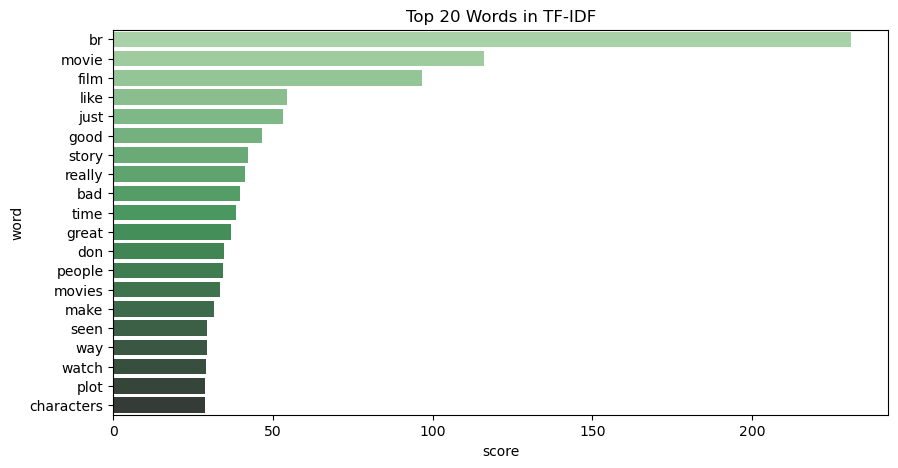

In [6]:
# Step 5, b: Compare Top Words in TF-IDF

tfidf_scores = X_tfidf.toarray().sum(axis=0)
words = tfidf_vectorizer.get_feature_names_out()
tfidf_freq = pd.DataFrame({'word': words, 'score': tfidf_scores})
tfidf_freq = tfidf_freq.sort_values(by='score', ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(x='score', y='word', data=tfidf_freq, palette="Greens_d")
plt.title("Top 20 Words in TF-IDF")
plt.show()